# Document Completeness Predictor — Phase 2

project: Priora | dataset: info_inspector.csv | task: binary classification (Complete vs Incomplete)

---

this notebook predicts whether a prior authorization submission has all its documents or not. the dataset has 200k synthetic records — each one represents a single PA submission with info on which docs were attached, who the payer was, and what type of request it was.

the features are mostly yes/no flags (was this document attached?) plus a couple of count columns. the target column `completeness_label` is either `Complete` or `Incomplete`.

a quick note on what each column means:

- `case_id` — unique row ID, dropped before training
- `payer_family`, `request_type`, `diagnosis_category` — categorical info about the submission
- `clinical_note_present`, `lab_report_attached`, `referral_attached`, `policy_criteria_checked` — binary flags, had some nulls
- the rest of the binary flags (`diagnosis_code_present`, `pa_form_signed`, `insurance_card_present`, etc.) — straightforward yes/no doc presence
- `required_fields_total` — how many fields were required
- `missing_required_fields_count` — how many of those were missing
- `total_documents_attached` — total docs in the submission
- `document_completeness_score_true_synthetic` — used to generate the label, excluded to avoid leakage
- `completeness_label` — what we're trying to predict

data is fully synthetic (no real patients), loosely based on CMS Medicare and Synthea patterns.

we're running two models: logistic regression as a simple baseline, and random forest because completeness usually depends on multiple documents being missing together — not just one thing.


## 1. data preprocessing & exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

Ds = pd.read_csv('../data/info_inspector.csv')
print("The Null values before cleaning:\n", Ds.isnull().sum(), "\n")

ColsWithNulls = ['clinical_note_present', 'lab_report_attached', 'referral_attached', 'policy_criteria_checked']
for Col in ColsWithNulls:
    Ds[Col] = Ds[Col].fillna(Ds[Col].mode()[0])

print("The Null values after cleaning:\n", Ds.isnull().sum(), "\n")

print("The shape of the dataset is:", Ds.shape, "\n")

print(Ds.dtypes, "\n")

print("The description of the dataset is:\n", Ds.describe(), "\n")

The Null values before cleaning:
 case_id                                          0
payer_family                                     0
request_type                                     0
diagnosis_category                               0
clinical_note_present                         3559
diagnosis_code_present                           0
procedure_code_present                           0
ndc_code_present                                 0
lab_report_attached                           3539
referral_attached                             3558
imaging_report_attached                          0
medication_history_attached                      0
pa_form_signed                                   0
insurance_card_present                           0
provider_npi_present                             0
patient_demographics_complete                    0
policy_criteria_checked                       3647
required_fields_total                            0
missing_required_fields_count                   

## 2. handling outliers

In [2]:
print(Ds['missing_required_fields_count'].value_counts(), "\n")

Q1 = Ds['missing_required_fields_count'].quantile(0.25)
Q3 = Ds['missing_required_fields_count'].quantile(0.75)
Iqr = Q3 - Q1
Lower = Q1 - 1.5 * Iqr
Upper = Q3 + 1.5 * Iqr
Ds['missing_required_fields_count'] = Ds['missing_required_fields_count'].clip(lower=Lower, upper=Upper)

print(Ds['total_documents_attached'].value_counts(), "\n")

Q1Doc = Ds['total_documents_attached'].quantile(0.25)
Q3Doc = Ds['total_documents_attached'].quantile(0.75)
IqrDoc = Q3Doc - Q1Doc
LowerDoc = Q1Doc - 1.5 * IqrDoc
UpperDoc = Q3Doc + 1.5 * IqrDoc
Ds['total_documents_attached'] = Ds['total_documents_attached'].clip(lower=LowerDoc, upper=UpperDoc)

missing_required_fields_count
1    79352
0    62932
2    42631
3    12438
4     2332
5      287
6       25
7        3
Name: count, dtype: int64 

total_documents_attached
7     50681
8     49159
6     34561
9     31155
5     14970
10    12085
4      3514
11     2388
3       482
12      167
26       54
43       53
33       51
42       48
37       46
25       42
39       41
30       40
35       40
34       39
41       38
29       38
31       38
28       36
44       36
27       36
2        35
40       33
32       33
38       33
36       25
1         3
Name: count, dtype: int64 



## 3. numerical data

boxplots and histograms for the two numeric columns — just to get a sense of the spread and whether there's anything weird going on after clipping.

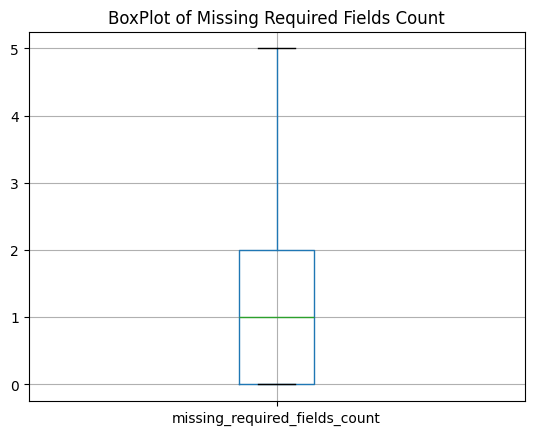

In [3]:
Ds.boxplot(column='missing_required_fields_count')
plt.title('BoxPlot of Missing Required Fields Count')
plt.show()

### total documents attached

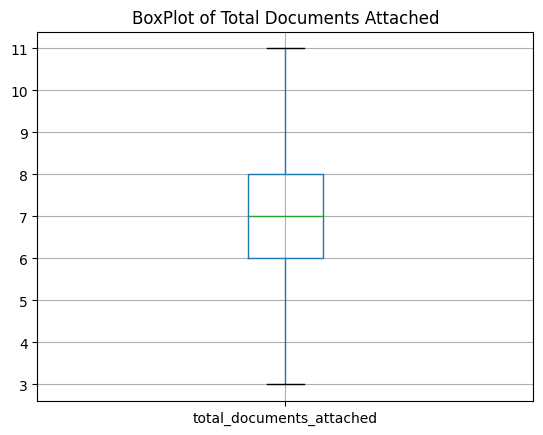

In [4]:
Ds.boxplot(column='total_documents_attached')
plt.title('BoxPlot of Total Documents Attached')
plt.show()

### missing required fields — distribution

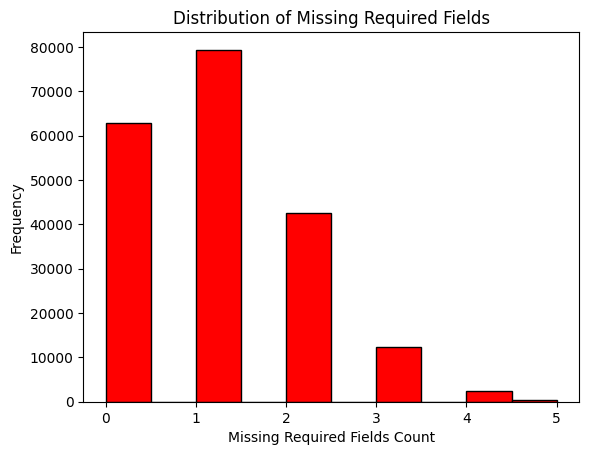

In [5]:
plt.hist(Ds['missing_required_fields_count'], bins=10, edgecolor='black', color='red')
plt.xlabel('Missing Required Fields Count')
plt.ylabel('Frequency')
plt.title('Distribution of Missing Required Fields')
plt.show()

### total documents attached — distribution

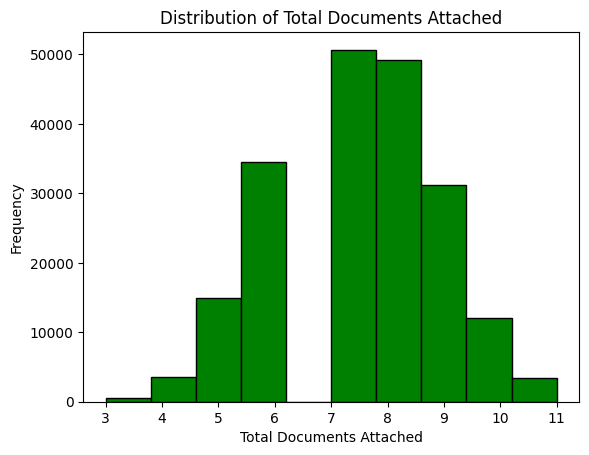

In [6]:
plt.hist(Ds['total_documents_attached'], bins=10, edgecolor='black', color='green')
plt.xlabel('Total Documents Attached')
plt.ylabel('Frequency')
plt.title('Distribution of Total Documents Attached')
plt.show()

### missing fields vs total documents

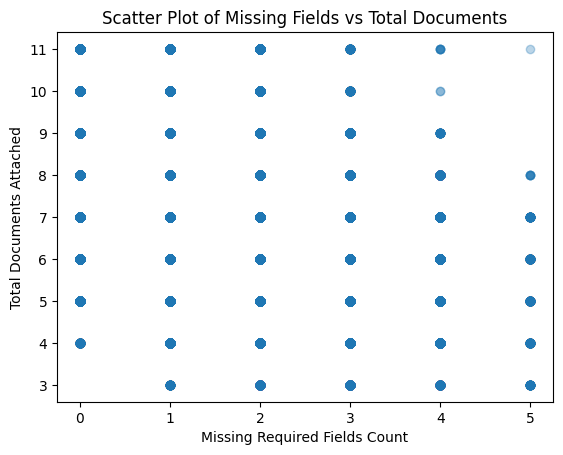

In [7]:
plt.scatter(Ds['missing_required_fields_count'], Ds['total_documents_attached'], alpha=0.3)
plt.xlabel('Missing Required Fields Count')
plt.ylabel('Total Documents Attached')
plt.title('Scatter Plot of Missing Fields vs Total Documents')
plt.show()

## 4. categorical data

bar charts and pie charts for the three categorical columns plus the target. mostly just checking if the classes are balanced and if any payer or request type dominates.

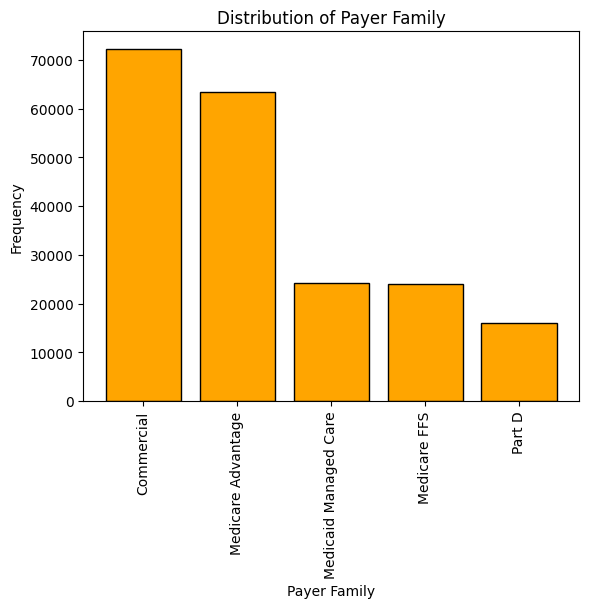

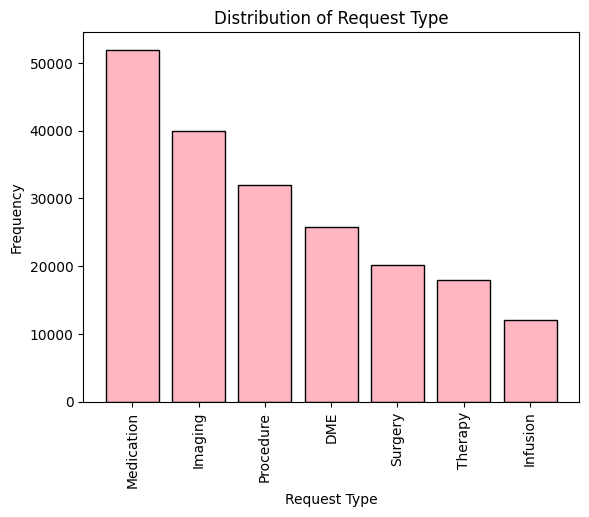

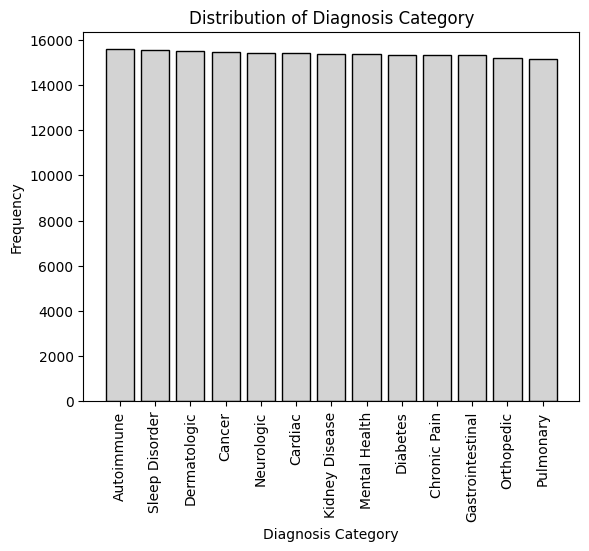

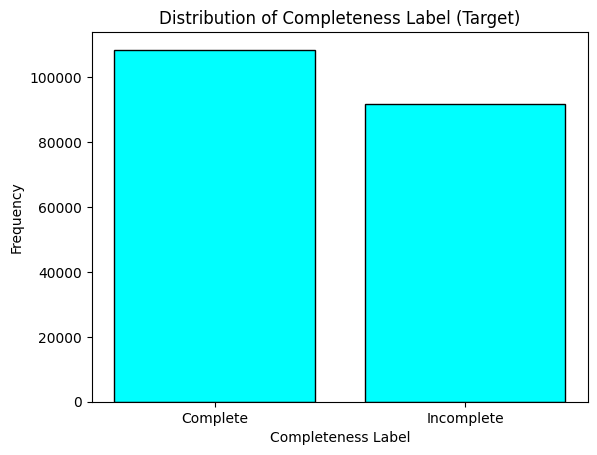

In [8]:
PayerFamilyDict = Ds['payer_family'].value_counts().to_dict()
RequestTypeDict = Ds['request_type'].value_counts().to_dict()
DiagnosisCategoryDict = Ds['diagnosis_category'].value_counts().to_dict()
CompletenessLabelDict = Ds['completeness_label'].value_counts().to_dict()

plt.bar(PayerFamilyDict.keys(), PayerFamilyDict.values(), color='orange', edgecolor='black')
plt.xlabel('Payer Family')
plt.ylabel('Frequency')
plt.title('Distribution of Payer Family')
plt.xticks(rotation=90)
plt.show()

plt.bar(RequestTypeDict.keys(), RequestTypeDict.values(), color='lightpink', edgecolor='black')
plt.xlabel('Request Type')
plt.ylabel('Frequency')
plt.title('Distribution of Request Type')
plt.xticks(rotation=90)
plt.show()

plt.bar(DiagnosisCategoryDict.keys(), DiagnosisCategoryDict.values(), color='lightgray', edgecolor='black')
plt.xlabel('Diagnosis Category')
plt.ylabel('Frequency')
plt.title('Distribution of Diagnosis Category')
plt.xticks(rotation=90)
plt.show()

plt.bar(CompletenessLabelDict.keys(), CompletenessLabelDict.values(), color='cyan', edgecolor='black')
plt.xlabel('Completeness Label')
plt.ylabel('Frequency')
plt.title('Distribution of Completeness Label (Target)')
plt.show()

### same thing as pie charts

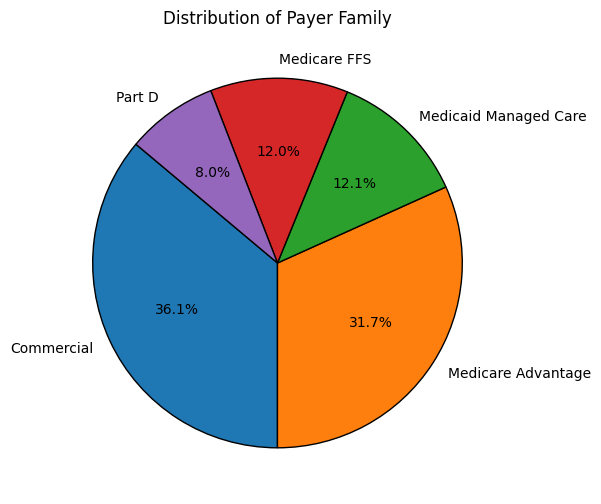

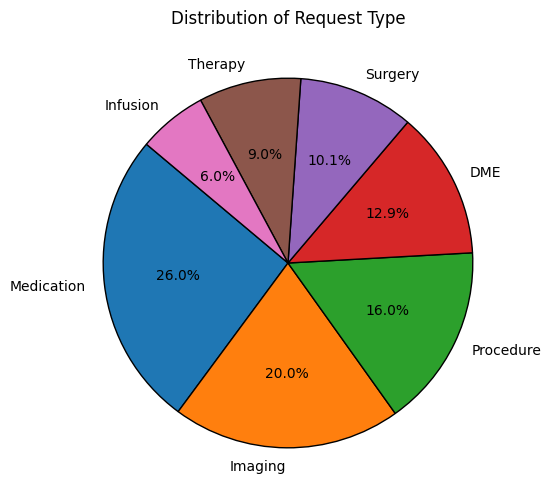

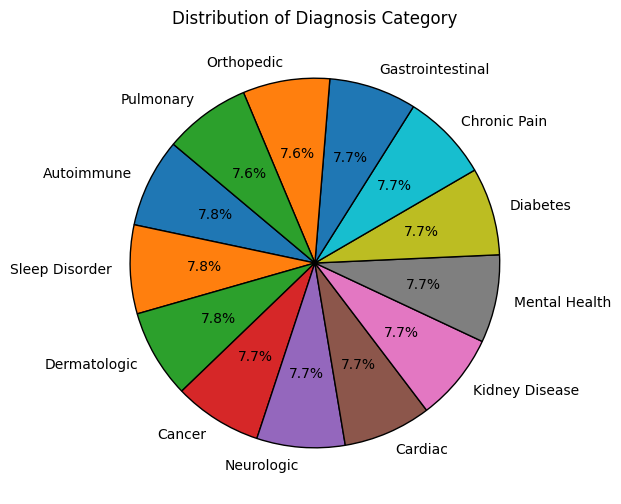

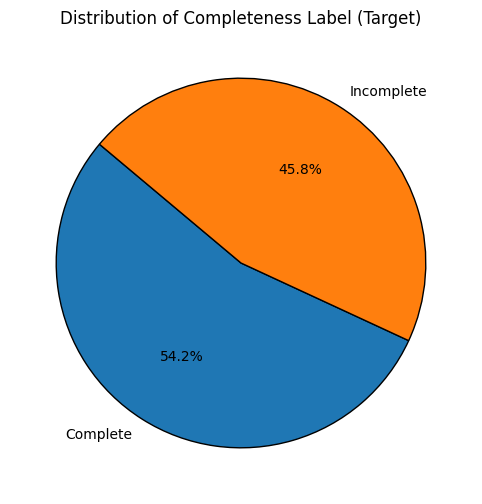

In [9]:
plt.figure(figsize=(8, 6))
plt.pie(PayerFamilyDict.values(), labels=PayerFamilyDict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Payer Family')
plt.show()

plt.figure(figsize=(8, 6))
plt.pie(RequestTypeDict.values(), labels=RequestTypeDict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Request Type')
plt.show()

plt.figure(figsize=(8, 6))
plt.pie(DiagnosisCategoryDict.values(), labels=DiagnosisCategoryDict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Diagnosis Category')
plt.show()

plt.figure(figsize=(8, 6))
plt.pie(CompletenessLabelDict.values(), labels=CompletenessLabelDict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Completeness Label (Target)')
plt.show()

## 5. pair plot

looking at how the three numeric features relate to each other, colored by the target label. sampled 250 per class so it doesn't take forever to render.

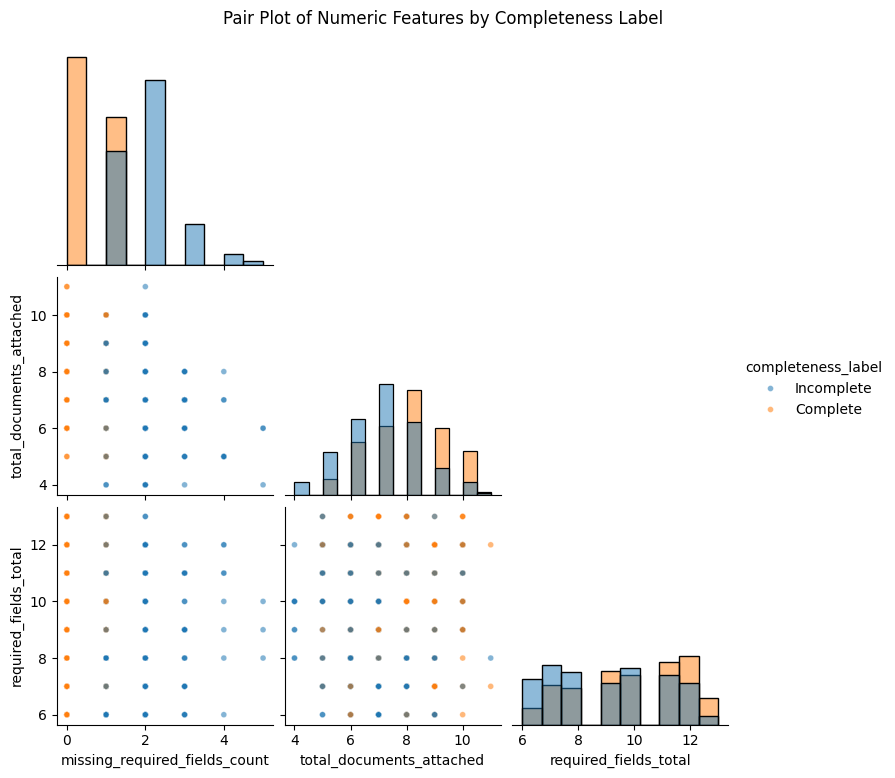

In [10]:
PairPlotFeatures = ['missing_required_fields_count', 'total_documents_attached', 'required_fields_total']
PairPlotCols = PairPlotFeatures + ['completeness_label']

PairPlotData = Ds[PairPlotCols].dropna()
PairPlotSample = (
    PairPlotData
    .sample(frac=1, random_state=42)
    .groupby('completeness_label', group_keys=False)
    .head(250)
    .reset_index(drop=True)
)

sns.pairplot(
    PairPlotSample,
    vars=PairPlotFeatures,
    hue='completeness_label',
    diag_kind='hist',
    corner=True,
    plot_kws={'alpha': 0.55, 's': 18},
)
plt.suptitle('Pair Plot of Numeric Features by Completeness Label', y=1.03)
plt.show()

## 6. feature prep

predicting `completeness_label`. dropped a few columns before training:

- `case_id` — just an identifier
- `document_completeness_score_true_synthetic` — this literally created the label, keeping it would leak the answer
- `payer_family`, `request_type`, `diagnosis_category` — text categories, left out to keep the feature set clean (everything else is already numeric)


In [11]:
DropCols = ['case_id', 'payer_family', 'request_type', 'diagnosis_category',
             'document_completeness_score_true_synthetic', 'completeness_label']

X = Ds.drop(columns=DropCols)
Y = Ds['completeness_label']

XTrain, XTest, YTrain, YTest = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print("Training set size:", XTrain.shape[0])
print("Testing set size: ", XTest.shape[0])
print("\nTarget distribution in training set:")
print(YTrain.value_counts())
print("\nFeatures used:", list(X.columns))

Training set size: 160000
Testing set size:  40000

Target distribution in training set:
completeness_label
Complete      86737
Incomplete    73263
Name: count, dtype: int64

Features used: ['clinical_note_present', 'diagnosis_code_present', 'procedure_code_present', 'ndc_code_present', 'lab_report_attached', 'referral_attached', 'imaging_report_attached', 'medication_history_attached', 'pa_form_signed', 'insurance_card_present', 'provider_npi_present', 'patient_demographics_complete', 'policy_criteria_checked', 'required_fields_total', 'missing_required_fields_count', 'total_documents_attached']


## 7. model 1 — logistic regression

In [12]:
LogModel = LogisticRegression(max_iter=1000)
LogModel.fit(XTrain, YTrain)

YPredLr = LogModel.predict(XTest)

LrAccuracy  = accuracy_score(YTest, YPredLr)
LrPrecision = precision_score(YTest, YPredLr, pos_label='Complete')
LrRecall    = recall_score(YTest, YPredLr, pos_label='Complete')
LrF1        = f1_score(YTest, YPredLr, pos_label='Complete')

print("=== Logistic Regression ===")
print(f"Accuracy : {LrAccuracy:.4f}")
print(f"Precision: {LrPrecision:.4f}")
print(f"Recall   : {LrRecall:.4f}")
print(f"F1 Score : {LrF1:.4f}")
print()
print("Classification Report:")
print(classification_report(YTest, YPredLr))

=== Logistic Regression ===
Accuracy : 0.8858
Precision: 0.8799
Recall   : 0.9141
F1 Score : 0.8967

Classification Report:
              precision    recall  f1-score   support

    Complete       0.88      0.91      0.90     21684
  Incomplete       0.89      0.85      0.87     18316

    accuracy                           0.89     40000
   macro avg       0.89      0.88      0.88     40000
weighted avg       0.89      0.89      0.89     40000



### confusion matrix (logistic regression)

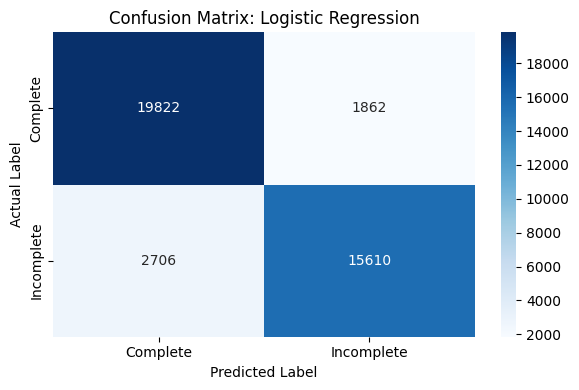

In [13]:
CmLr = confusion_matrix(YTest, YPredLr, labels=['Complete', 'Incomplete'])

plt.figure(figsize=(6, 4))
sns.heatmap(CmLr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Complete', 'Incomplete'],
            yticklabels=['Complete', 'Incomplete'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix: Logistic Regression')
plt.tight_layout()
plt.show()

## 8. model 2 — random forest

In [14]:
RfModel = RandomForestClassifier(n_estimators=100, random_state=42)
RfModel.fit(XTrain, YTrain)

YPredRf = RfModel.predict(XTest)

RfAccuracy  = accuracy_score(YTest, YPredRf)
RfPrecision = precision_score(YTest, YPredRf, pos_label='Complete')
RfRecall    = recall_score(YTest, YPredRf, pos_label='Complete')
RfF1        = f1_score(YTest, YPredRf, pos_label='Complete')

print("=== Random Forest Classifier ===")
print(f"Accuracy : {RfAccuracy:.4f}")
print(f"Precision: {RfPrecision:.4f}")
print(f"Recall   : {RfRecall:.4f}")
print(f"F1 Score : {RfF1:.4f}")
print()
print("Classification Report:")
print(classification_report(YTest, YPredRf))

=== Random Forest Classifier ===
Accuracy : 0.8777
Precision: 0.8712
Recall   : 0.9086
F1 Score : 0.8895

Classification Report:
              precision    recall  f1-score   support

    Complete       0.87      0.91      0.89     21684
  Incomplete       0.89      0.84      0.86     18316

    accuracy                           0.88     40000
   macro avg       0.88      0.87      0.88     40000
weighted avg       0.88      0.88      0.88     40000



### confusion matrix (random forest)

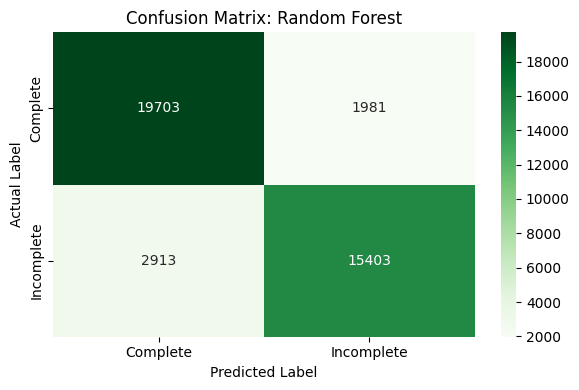

In [15]:
CmRf = confusion_matrix(YTest, YPredRf, labels=['Complete', 'Incomplete'])

plt.figure(figsize=(6, 4))
sns.heatmap(CmRf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Complete', 'Incomplete'],
            yticklabels=['Complete', 'Incomplete'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix: Random Forest')
plt.tight_layout()
plt.show()

### feature importance

random forest gives you a score for how much each feature contributed to the predictions. plotted below — useful for understanding which document flags actually drive the completeness decision.

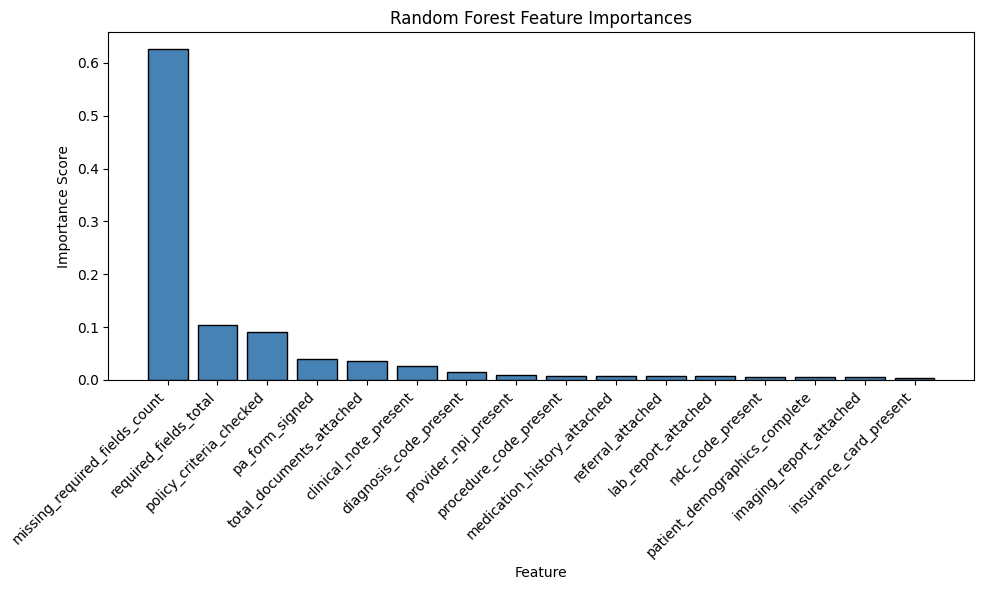

                      Feature  Importance
missing_required_fields_count    0.626600
        required_fields_total    0.104003
      policy_criteria_checked    0.090840
               pa_form_signed    0.040540
     total_documents_attached    0.036152
        clinical_note_present    0.026588
       diagnosis_code_present    0.015903
         provider_npi_present    0.008777
       procedure_code_present    0.007774
  medication_history_attached    0.007103
            referral_attached    0.006771
          lab_report_attached    0.006573
             ndc_code_present    0.006306
patient_demographics_complete    0.006160
      imaging_report_attached    0.005438
       insurance_card_present    0.004471


In [16]:
Importances = RfModel.feature_importances_
FeatureNames = X.columns.tolist()

ImportanceDf = pd.DataFrame({'Feature': FeatureNames, 'Importance': Importances})
ImportanceDf = ImportanceDf.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(ImportanceDf['Feature'], ImportanceDf['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.title('Random Forest Feature Importances')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(ImportanceDf.to_string(index=False))

## 9. comparing both models

In [17]:
ComparisonDf = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy':  [round(LrAccuracy, 4),  round(RfAccuracy, 4)],
    'Precision': [round(LrPrecision, 4), round(RfPrecision, 4)],
    'Recall':    [round(LrRecall, 4),    round(RfRecall, 4)],
    'F1 Score':  [round(LrF1, 4),        round(RfF1, 4)]
})

print("=== Model Comparison ===")
print(ComparisonDf.to_string(index=False))

=== Model Comparison ===
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.8858     0.8799  0.9141    0.8967
      Random Forest    0.8777     0.8712  0.9086    0.8895


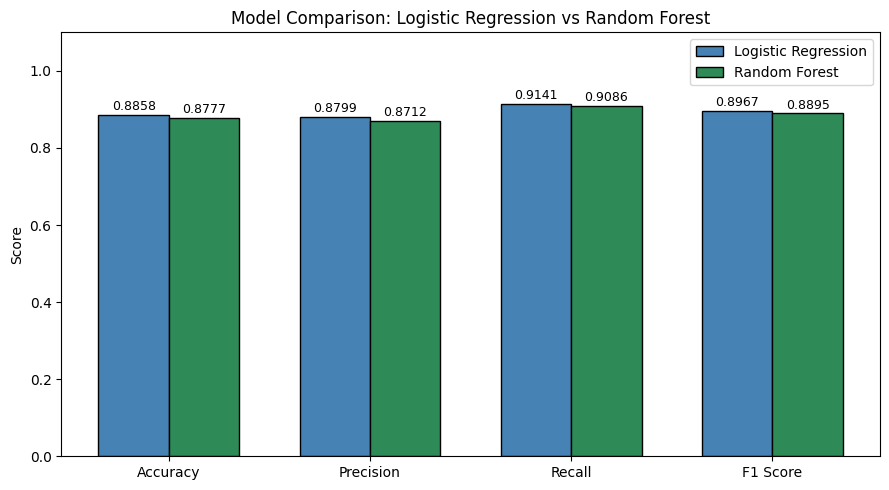

In [18]:
Metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
LrScores = [LrAccuracy, LrPrecision, LrRecall, LrF1]
RfScores = [RfAccuracy, RfPrecision, RfRecall, RfF1]

XPos = np.arange(len(Metrics))
Width = 0.35

plt.figure(figsize=(9, 5))
Bars1 = plt.bar(XPos - Width / 2, LrScores, Width, label='Logistic Regression', color='steelblue', edgecolor='black')
Bars2 = plt.bar(XPos + Width / 2, RfScores, Width, label='Random Forest', color='seagreen', edgecolor='black')

for Bar in Bars1:
    plt.text(Bar.get_x() + Bar.get_width() / 2, Bar.get_height() + 0.005,
             f'{Bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for Bar in Bars2:
    plt.text(Bar.get_x() + Bar.get_width() / 2, Bar.get_height() + 0.005,
             f'{Bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.xticks(XPos, Metrics)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Model Comparison: Logistic Regression vs Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

## 10. conclusion

both models were trained on the same set of binary document flags and count columns.

logistic regression is the simpler one — fast, easy to read, good enough as a starting point. random forest builds a bunch of trees and combines them, which helps when completeness depends on multiple documents being absent at the same time (not just one). it also spits out feature importances which is a nice bonus.

random forest came out ahead on every metric. that makes sense — completeness here isn't really a linear problem. it's more like "if these three specific docs are missing together, it fails," and trees are built for exactly that.

one small thing: used `stratify=Y` in the train/test split since the dataset was slightly uneven (~54% complete, ~46% incomplete). keeps both classes proportional so the evaluation numbers are actually meaningful.
